## Image Analysis and Processing

## Introduction

The objective of this project is to develop and evaluate intelligent systems for pneumonia detection from chest X-ray images. The analysis follows a complete machine learning pipeline, including dataset exploration and visualization, image preprocessing, model development, and performance evaluation.

For the classical machine learning approach, HOG and GLCM feature descriptors are extracted from the X-ray images. These descriptors capture complementary information: HOG represents structural patterns such as edges and shapes, while GLCM captures image texture characteristics. The extracted features are used to train and evaluate Random Forest and Linear SVM classifiers.

For the deep learning approach, both a custom Convolutional Neural Network (CNN) and a pretrained EfficientNetB0 model are investigated. The custom CNN serves as a baseline architecture that learns image features directly from the data, while EfficientNetB0 leverages transfer learning from a pretrained model.

Model performance is evaluated using accuracy, F1-score, and confusion matrices. Finally, the binary classification problem is extended to three classes — Normal, Bacterial Pneumonia, and Viral Pneumonia — to investigate whether the model can distinguish between different pneumonia subtypes in addition to detecting the disease itself.

## Environment Setup



In [ ]:
# Install the Kaggle API
!pip install -q kaggle

# Download the Chest X-Ray Pneumonia dataset from Kaggle
# Kaggle credentials must be configured before running this cell.
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# Extract the dataset
!unzip -q chest-xray-pneumonia.zip -d chest_xray

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:16<00:00, 150MB/s]



# Imports

In [ ]:
# standard libraries
import os
import time
import random
import shutil

# numerical & visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# image processing
import cv2
from skimage.feature import hog, graycomatrix, graycoprops

# classical machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

# deep learning
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# progress bar
from tqdm import tqdm

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Dataset paths ─────────────────────────────────────────────────────────────
BASE_DIR = os.path.join("chest_xray", "chest_xray")
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")
TEST_DIR = os.path.join(BASE_DIR, "test")

# Data Exploration


Before building any models, it is useful to examine the structure of the dataset and the available data splits. This step helps verify that the images are organized correctly and provides an overview of the data that will be used for training, validation, and testing.

In [ ]:
# ── Dataset Summary ───────────────────────────────────────────────────────────
# Define the dataset splits and their corresponding directory paths
splits = {
    "train": TRAIN_DIR,
    "val":   VAL_DIR,
    "test":  TEST_DIR
}

# Two binary classes: healthy vs pneumonia-infected
classes = ["NORMAL", "PNEUMONIA"]

# Count and display the number of images per class for each split
print("Dataset Summary")
print("=" * 50)

total_images = 0

for split, path in splits.items():
    print(f"\n{split.upper()} SET")
    split_total = 0

    for cls in classes:
        cls_path = os.path.join(path, cls)

        # Count only valid image files (ignore system files like .DS_Store)
        count = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith((".jpeg", ".jpg", ".png"))
        ])

        split_total  += count
        total_images += count
        print(f"  {cls:<10}: {count}")

    print(f"  Total      : {split_total}")

print("\n" + "=" * 50)
print(f"Total Images in Dataset: {total_images}")

Dataset Summary

TRAIN SET
  NORMAL    : 1341
  PNEUMONIA : 3875
  Total      : 5216

VAL SET
  NORMAL    : 8
  PNEUMONIA : 8
  Total      : 16

TEST SET
  NORMAL    : 234
  PNEUMONIA : 390
  Total      : 624

Total Images in Dataset: 5856


## Initial Observations

The dataset contains 5,856 chest X-ray images in total. Most of the images belong to the Pneumonia class, indicating a noticeable class imbalance. In addition, the original validation set contains only 16 images, which is too small for reliable model evaluation. For this reason, a new validation set will be created from the training data in the following steps.

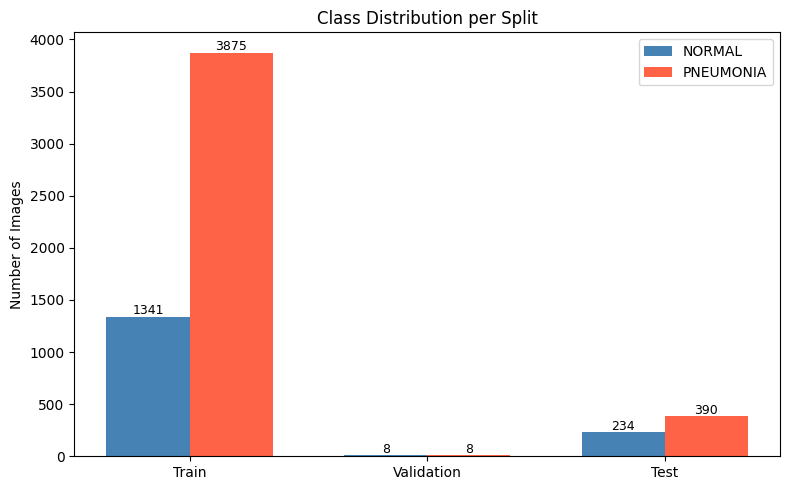

In [ ]:
# ── Class Imbalance Visualization ─────────────────────────────────────────────
# Count Normal and Pneumonia images for each split
normal_counts    = []
pneumonia_counts = []

for split, path in splits.items():
    normal_counts.append(
        len([f for f in os.listdir(os.path.join(path, "NORMAL"))
             if f.lower().endswith((".jpeg", ".jpg", ".png"))])
    )
    pneumonia_counts.append(
        len([f for f in os.listdir(os.path.join(path, "PNEUMONIA"))
             if f.lower().endswith((".jpeg", ".jpg", ".png"))])
    )

# Set up grouped bar chart parameters
split_names = ["Train", "Validation", "Test"]
x     = range(len(split_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

# Plot one bar group per class
bars1 = ax.bar([i - width/2 for i in x], normal_counts,    width, label="NORMAL",    color="steelblue")
bars2 = ax.bar([i + width/2 for i in x], pneumonia_counts, width, label="PNEUMONIA", color="tomato")

ax.set_title("Class Distribution per Split")
ax.set_xticks(list(x))
ax.set_xticklabels(split_names)
ax.set_ylabel("Number of Images")
ax.legend()

# Annotate each bar with its exact count
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 20,
            str(int(bar.get_height())),
            ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## Class Distribution

The class distribution is not balanced, especially in the training set where Pneumonia cases are considerably more frequent than Normal cases. This imbalance should be taken into account during model development, as it may influence the learning process and bias predictions toward the majority class.

The figure also highlights the extremely small size of the original validation set. To obtain more reliable performance estimates, a new validation split will be created from the training data in the next step.

train: Normal=1341, Bacterial=2530, Viral=1345
val: Normal=8, Bacterial=8, Viral=0
test: Normal=234, Bacterial=242, Viral=148


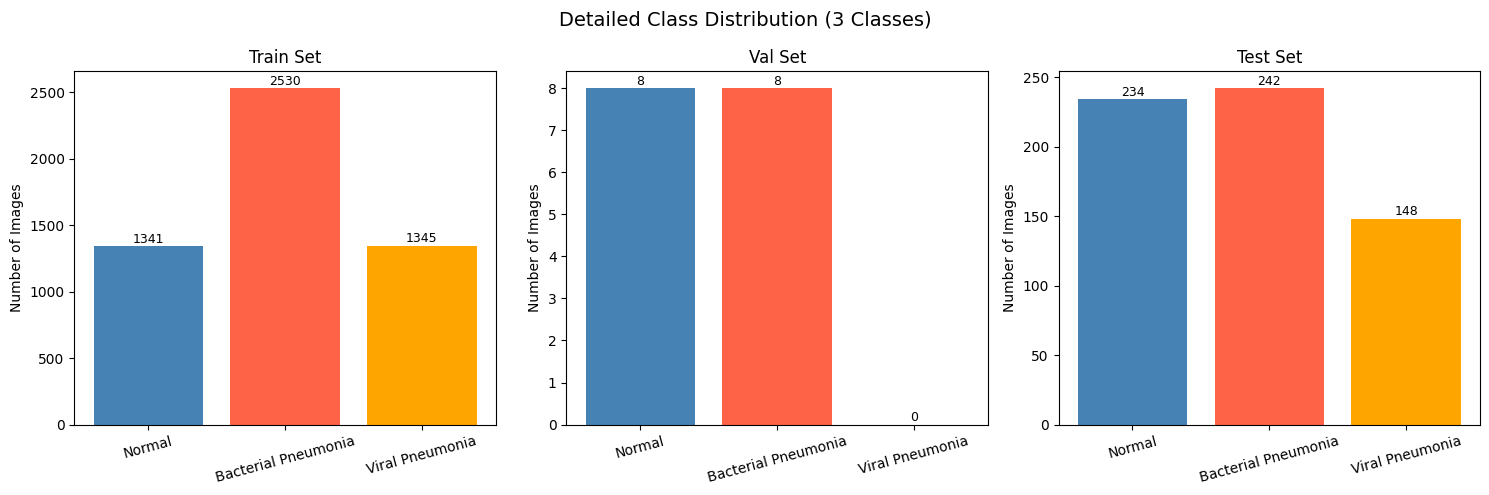

In [ ]:
# ── Detailed Class Distribution (3 Classes) ───────────────────────────────────
# The PNEUMONIA folder contains both bacterial and viral cases,
# distinguishable via the filename pattern:
#   person{id}_bacteria_{n}.jpeg  →  Bacterial Pneumonia
#   person{id}_virus_{n}.jpeg     →  Viral Pneumonia

detailed_counts = {}

for split, path in splits.items():
    bacterial, viral = 0, 0

    # Count Normal images (valid image files only)
    normal_path = os.path.join(path, "NORMAL")
    normal = len([f for f in os.listdir(normal_path)
                  if f.lower().endswith((".jpeg", ".jpg", ".png"))])

    # Separate Bacterial vs Viral Pneumonia based on filename keywords
    pneumonia_path = os.path.join(path, "PNEUMONIA")
    for fname in os.listdir(pneumonia_path):
        if "bacteria" in fname.lower():
            bacterial += 1
        elif "virus" in fname.lower():
            viral += 1

    detailed_counts[split] = {
        "Normal":               normal,
        "Bacterial Pneumonia":  bacterial,
        "Viral Pneumonia":      viral
    }
    print(f"{split}: Normal={normal}, Bacterial={bacterial}, Viral={viral}")

# Plot one subplot per split showing the 3-class breakdown
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ["steelblue", "tomato", "orange"]

for i, split in enumerate(["train", "val", "test"]):
    labels = list(detailed_counts[split].keys())
    values = list(detailed_counts[split].values())

    axes[i].bar(labels, values, color=colors)
    axes[i].set_title(f"{split.capitalize()} Set")
    axes[i].set_ylabel("Number of Images")

    # Annotate each bar with its exact count
    for j, v in enumerate(values):
        axes[i].text(j, v + max(values) * 0.01, str(v),
                     ha="center", fontsize=9)

    axes[i].tick_params(axis="x", rotation=15)

plt.suptitle("Detailed Class Distribution (3 Classes)", fontsize=14)
plt.tight_layout()
plt.show()

## Detailed Class Distribution

In addition to the binary classification problem, the dataset was also examined using the three original categories: Normal, Bacterial Pneumonia, and Viral Pneumonia.

The training and test sets contain samples from all three classes. However, the original validation set does not include any Viral Pneumonia images. This makes it unsuitable for evaluating a three-class classification model, since one of the target categories is completely missing.

For this reason, a new validation set will be created from the training data later in the notebook. This ensures that all classes are represented during model development and evaluation.

## Building a Unified Dataset

To simplify the analysis, all images are collected into a single dataframe containing the image path, the original dataset split, and the corresponding labels. Both the binary labels (Normal / Pneumonia) and the detailed labels (Normal / Bacterial Pneumonia / Viral Pneumonia) are stored, allowing the dataset to be used for both classification tasks later in the notebook.

In [ ]:
# ── Create DataFrame with Filepaths and Labels ────────────────────────────────
# Build a structured DataFrame storing each image's path, split, and class labels.
# Two label columns are created:
#   binary_class   : Normal vs Pneumonia (2-class problem)
#   detailed_class : Normal vs Bacterial Pneumonia vs Viral Pneumonia (3-class problem)

records = []
for split, path in splits.items():
    for cls in classes:
        cls_path = os.path.join(path, cls)
        for fname in os.listdir(cls_path):
            if fname.lower().endswith((".jpeg", ".jpg", ".png")):
                filepath = os.path.join(cls_path, fname)

                # Determine detailed class from filename keywords
                if cls == "NORMAL":
                    detailed_class = "Normal"
                elif "bacteria" in fname.lower():
                    detailed_class = "Bacterial Pneumonia"
                elif "virus" in fname.lower():
                    detailed_class = "Viral Pneumonia"
                else:
                    detailed_class = "Unknown"

                records.append({
                    "filepath":       filepath,
                    "original_split": split,
                    "binary_class":   "Normal" if cls == "NORMAL" else "Pneumonia",
                    "detailed_class": detailed_class
                })

df = pd.DataFrame(records)

# Display a summary of the resulting DataFrame
print(df.head())
print(f"\nTotal images: {len(df)}")
print("\nCounts by original split and binary class:")
print(df.groupby(["original_split", "binary_class"]).size().unstack(fill_value=0))
print("\nCounts by original split and detailed class:")
print(df.groupby(["original_split", "detailed_class"]).size().unstack(fill_value=0))

                                            filepath original_split  \
0  /content/chest_xray/chest_xray/train/NORMAL/NO...          train   
1  /content/chest_xray/chest_xray/train/NORMAL/NO...          train   
2  /content/chest_xray/chest_xray/train/NORMAL/IM...          train   
3  /content/chest_xray/chest_xray/train/NORMAL/NO...          train   
4  /content/chest_xray/chest_xray/train/NORMAL/IM...          train   

  binary_class detailed_class  
0       Normal         Normal  
1       Normal         Normal  
2       Normal         Normal  
3       Normal         Normal  
4       Normal         Normal  

Total images: 5856

Counts by original split and binary class:
binary_class    Normal  Pneumonia
original_split                   
test               234        390
train             1341       3875
val                  8          8

Counts by original split and detailed class:
detailed_class  Bacterial Pneumonia  Normal  Viral Pneumonia
original_split                          

## Dataset Overview

The resulting dataframe contains all 5,856 chest X-ray images available in the dataset. Having the metadata in a tabular format makes it easier to inspect class distributions, create custom train-validation splits, and prepare the data for both classical machine learning and deep learning experiments.

## Visual Inspection of the Images

Before applying any preprocessing or training models, it is useful to examine a few sample images from each category. This provides a better understanding of the visual characteristics of the dataset and highlights some of the differences between normal lungs and pneumonia cases.

Displaying Sample X-Ray Images


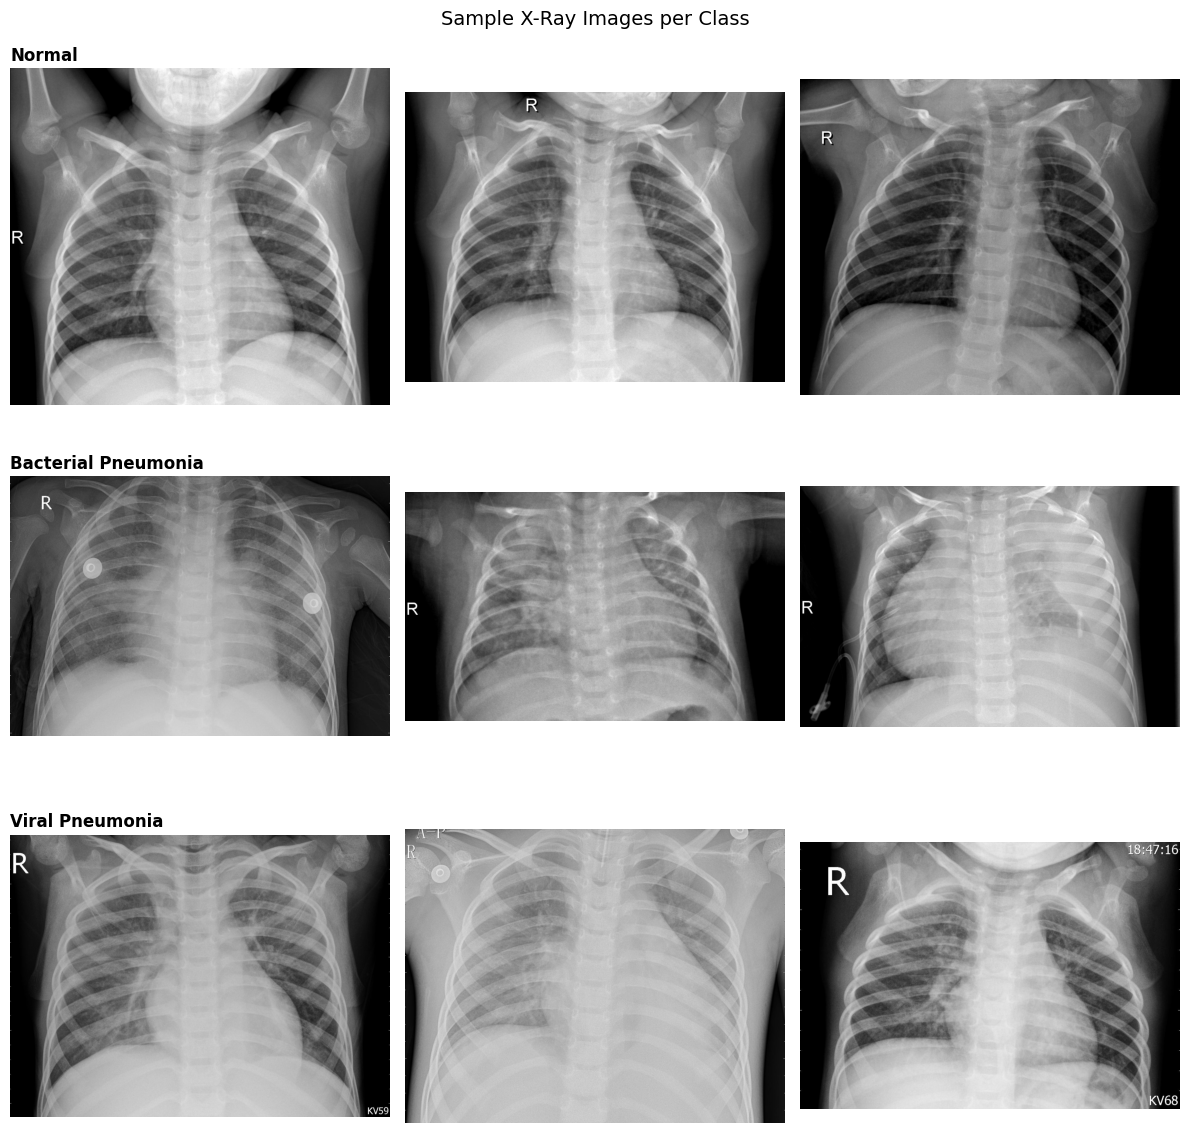

In [ ]:
# ── Visualizing Sample X-Rays ─────────────────────────────────────────────────
# Display sample images from each detailed class (Normal, Bacterial, Viral)
# to get a visual sense of the data before preprocessing.

def plot_samples(dataframe, num_samples=3):
    classes = dataframe["detailed_class"].unique()
    fig, axes = plt.subplots(
        len(classes),
        num_samples,
        figsize=(4 * num_samples, 4 * len(classes))
    )
    for i, cls in enumerate(classes):
        # Randomly sample images from each class
        sample_df = dataframe[
            dataframe["detailed_class"] == cls
        ].sample(num_samples, random_state=SEED)

        for j, (_, row) in enumerate(sample_df.iterrows()):
            # Read image and convert BGR → RGB for correct color display
            img = cv2.imread(row["filepath"])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            ax = axes[i, j] if len(classes) > 1 else axes[j]
            ax.imshow(img)
            ax.axis("off")

            # Label the first column with the class name
            if j == 0:
                ax.set_title(cls, loc="left", fontweight="bold")

    plt.suptitle("Sample X-Ray Images per Class", fontsize=14)
    plt.tight_layout()
    plt.show()

print("Displaying Sample X-Ray Images")
plot_samples(df, num_samples=3)

## Observations

Although the three classes share many visual similarities, some differences can already be observed. Normal chest X-rays generally appear clearer, while pneumonia cases often show denser or more opaque regions within the lungs. At the same time, distinguishing between bacterial and viral pneumonia based solely on visual inspection is not straightforward, which makes the classification task more challenging.

## Pixel Intensity Analysis

Before applying preprocessing techniques, the distribution of pixel intensities is examined for the two main classes. This provides a general view of the image characteristics and helps identify potential differences between normal and pneumonia X-rays.

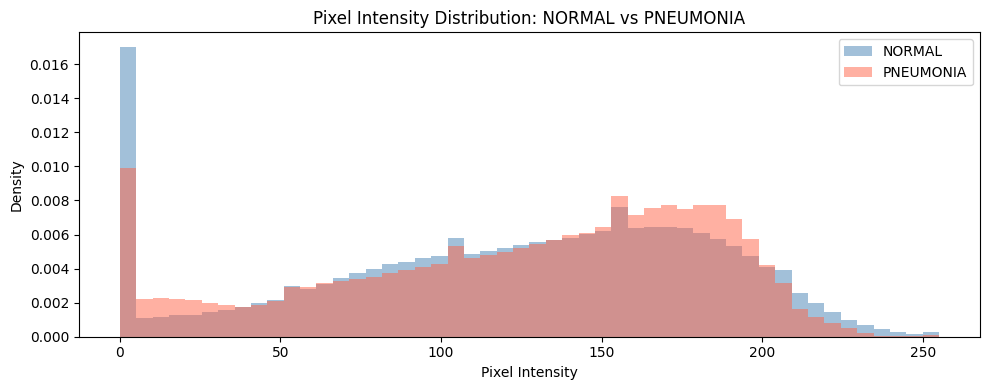

In [ ]:
# ── Pixel Intensity Distribution ──────────────────────────────────────────────
# Comparing the pixel intensity histograms of Normal vs Pneumonia images
# helps understand whether the two classes are visually distinguishable
# at the raw pixel level — before any preprocessing.

def get_pixel_values(split_path, cls, n=100):
    cls_path = os.path.join(split_path, cls)
    images   = [f for f in os.listdir(cls_path)
                if f.lower().endswith((".jpeg", ".jpg", ".png"))]
    samples  = random.sample(images, min(n, len(images)))
    pixels   = []
    for fname in samples:
        img = cv2.imread(os.path.join(cls_path, fname), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (224, 224))
        pixels.extend(img.flatten().tolist())
    return pixels

normal_pixels    = get_pixel_values(TRAIN_DIR, "NORMAL")
pneumonia_pixels = get_pixel_values(TRAIN_DIR, "PNEUMONIA")

# Plot overlapping histograms to compare intensity distributions
plt.figure(figsize=(10, 4))
plt.hist(normal_pixels,    bins=50, alpha=0.5, color="steelblue", label="NORMAL",    density=True)
plt.hist(pneumonia_pixels, bins=50, alpha=0.5, color="tomato",    label="PNEUMONIA", density=True)
plt.title("Pixel Intensity Distribution: NORMAL vs PNEUMONIA")
plt.xlabel("Pixel Intensity")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

## Observations

The two distributions overlap considerably, indicating that pneumonia cannot be detected based on pixel intensity alone. However, small differences can be observed in certain intensity ranges, suggesting that useful information may still be present in the images. This highlights the need for more advanced feature extraction and learning methods that can capture spatial patterns and textures rather than relying only on global intensity values.

## Creating a New Validation Set

The original validation set contains only 16 images and does not include any Viral Pneumonia cases. As a result, it is not suitable for model development or performance monitoring.

To obtain a more reliable validation set, the original training and validation images are combined and then split again using stratified sampling. This preserves the class proportions while ensuring that all classes are represented in both the training and validation sets.

The original test set remains unchanged and is reserved for the final evaluation of all models.

In [ ]:
# ── Creating a More Reliable Train/Validation Split ───────────────────────────
# The original validation set contains only 16 images (8 Normal, 8 Bacterial,
# 0 Viral Pneumonia), which is too small and unrepresentative for validation.
# Solution: merge train + val and create a new stratified 85/15 split,
# ensuring all 3 classes are proportionally represented in both sets.

from sklearn.model_selection import train_test_split

# Combine the original train and validation sets
train_val_df = df[df["original_split"].isin(["train", "val"])].copy()

# Keep the original test set unchanged for final evaluation
test_df = df[df["original_split"] == "test"].copy()

# Create a new stratified 85/15 train-validation split
# stratify=detailed_class ensures proportional class representation
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.15,
    stratify=train_val_df["detailed_class"],
    random_state=SEED
)

print("--- New Optimized Split Statistics ---")
print(f"Training Set Size  : {len(train_df)}")
print(f"Validation Set Size: {len(val_df)}")
print(f"Testing Set Size   : {len(test_df)}")
print("\nClass distribution in new train set:")
print(train_df["detailed_class"].value_counts())
print("\nClass distribution in new val set:")
print(val_df["detailed_class"].value_counts())

--- New Optimized Split Statistics ---
Training Set Size  : 4447
Validation Set Size: 785
Testing Set Size   : 624

Class distribution in new train set:
detailed_class
Bacterial Pneumonia    2157
Normal                 1147
Viral Pneumonia        1143
Name: count, dtype: int64

Class distribution in new val set:
detailed_class
Bacterial Pneumonia    381
Viral Pneumonia        202
Normal                 202
Name: count, dtype: int64


## New Split Statistics

The new split provides a substantially larger validation set while maintaining the original class proportions. This allows more reliable model selection and performance monitoring during training, especially for the three-class classification experiments.

# Image Preprocessing


Before extracting features or training the neural networks, a common preprocessing pipeline is applied to all images. The goal is to improve image quality, reduce noise, and ensure that all samples have a consistent format.

The same preprocessing steps are used throughout the notebook so that the different models are trained and evaluated under comparable conditions.

In [ ]:
# ── Base Image Preprocessing ──────────────────────────────────────────────────
# All images go through this common preprocessing pipeline before feature
# extraction (classical ML) or model training (neural network).
#
# Pipeline steps:
#   1. Grayscale loading   — X-rays carry no color information
#   2. Resize to 224×224   — uniform input size required by all models
#   3. Gaussian Blur       — reduces high-frequency noise from the scanner
#   4. CLAHE               — enhances local contrast to highlight lung structures
#                            (Contrast Limited Adaptive Histogram Equalization)

def preprocess_pipeline(image_path, target_size=(224, 224)):
    """
    Applies universal base preprocessing steps for chest X-rays.
    Returns both the original (grayscale) image and the preprocessed image.
    """
    # Load image in grayscale (X-rays are inherently grayscale)
    img_original = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img_original is None:
        print(f"Warning: Could not read image at {image_path}")
        return None, None

    # Resize to a uniform size for consistent feature extraction
    img_resized = cv2.resize(img_original, target_size)

    # Apply Gaussian Blur to reduce scanner noise
    img_blurred = cv2.GaussianBlur(img_resized, (3, 3), 0)

    # Apply CLAHE to enhance local contrast in lung regions
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_preprocessed = clahe.apply(img_blurred)

    return img_original, img_preprocessed

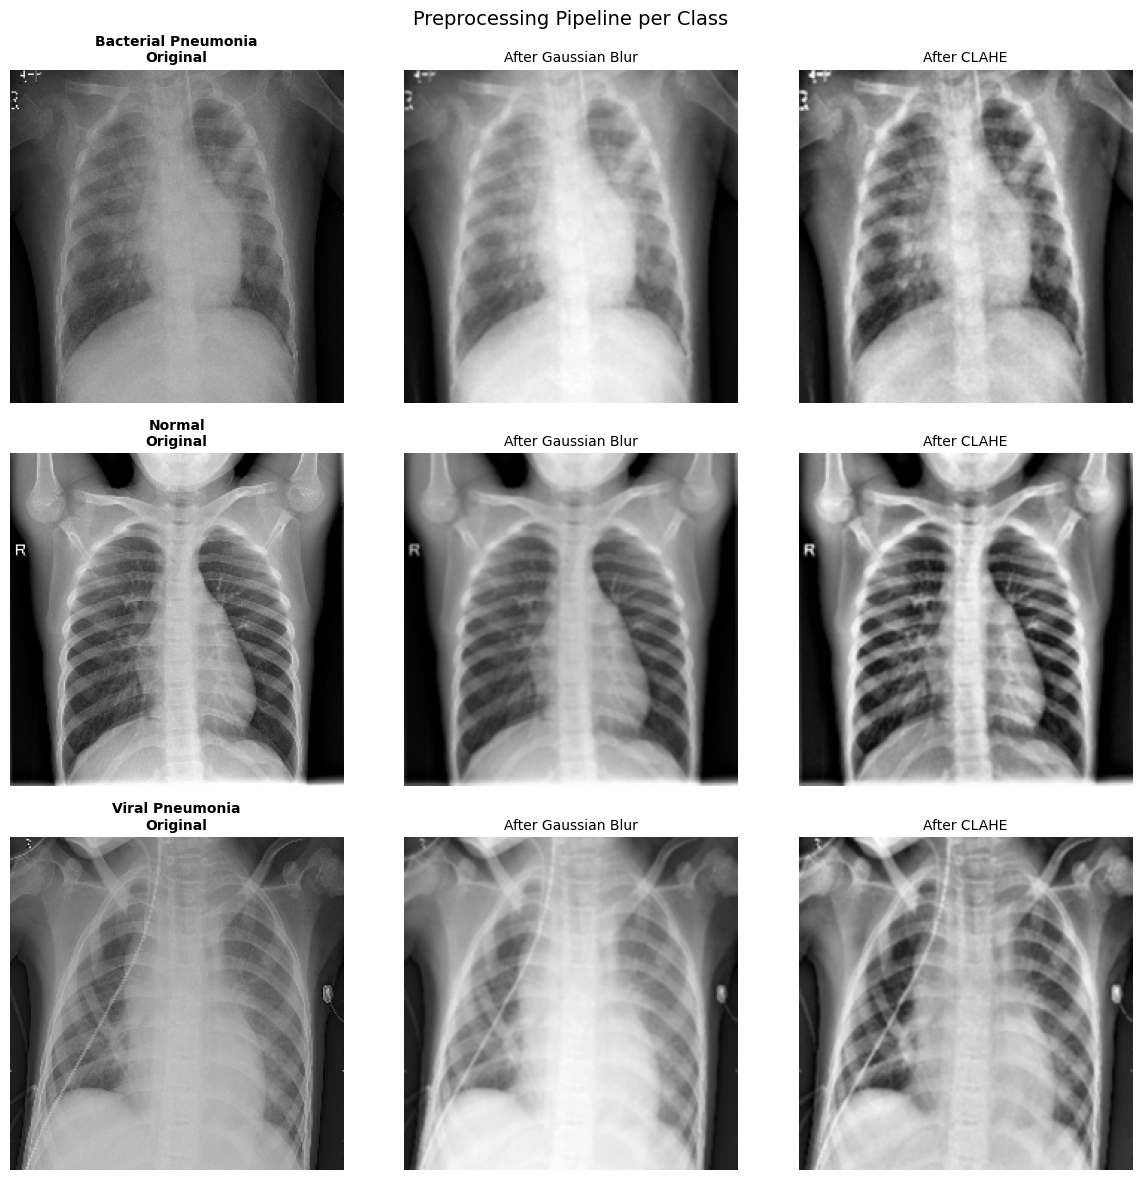

In [ ]:
# ── Preprocessing Pipeline Visualization ─────────────────────────────────────
# Visualize the effect of each preprocessing step on a sample image
# from each class: Original → Gaussian Blur → CLAHE

def visualize_preprocessing(dataframe, num_samples=1):
    """
    Displays the preprocessing steps side by side for one sample per class.
    Columns: Original | After Gaussian Blur | After CLAHE
    """
    classes = dataframe["detailed_class"].unique()
    steps   = ["Original", "After Gaussian Blur", "After CLAHE"]

    fig, axes = plt.subplots(
        len(classes), 3,
        figsize=(12, 4 * len(classes))
    )

    for i, cls in enumerate(classes):
        # Sample one image from this class
        sample = dataframe[dataframe["detailed_class"] == cls].sample(
            num_samples, random_state=SEED
        ).iloc[0]

        # Load and process step by step
        img_original = cv2.imread(sample["filepath"], cv2.IMREAD_GRAYSCALE)
        img_resized  = cv2.resize(img_original, (224, 224))
        img_blurred  = cv2.GaussianBlur(img_resized, (3, 3), 0)
        clahe        = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img_clahe    = clahe.apply(img_blurred)

        images = [img_resized, img_blurred, img_clahe]

        for j, (img, step) in enumerate(zip(images, steps)):
            ax = axes[i, j]
            ax.imshow(img, cmap="gray")
            ax.axis("off")
            # Class label on the left column
            if j == 0:
                ax.set_title(f"{cls}\n{step}", fontweight="bold", fontsize=10)
            else:
                ax.set_title(step, fontsize=10)

    plt.suptitle("Preprocessing Pipeline per Class", fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_preprocessing(train_df)

## Preprocessing Observations

The effect of each preprocessing step can be observed in the example images above. Gaussian blur slightly smooths the image and reduces high-frequency noise, while CLAHE enhances local contrast and makes lung structures more visible.

Although the overall appearance of the X-rays remains unchanged, the processed images exhibit clearer anatomical details and improved contrast. These enhancements can help both classical feature extraction methods and deep learning models focus on more informative patterns within the lungs.

# Feature Extraction for Classical Machine Learning



Classical machine learning models cannot work directly with raw images. Therefore, each X-ray image is converted into a numerical feature vector that summarizes its visual content.

To capture different aspects of the images, two complementary feature descriptors are used. HOG focuses on structural information such as edges and shapes, while GLCM captures texture characteristics based on the spatial relationships between pixel intensities. The resulting features are combined into a single representation that will be used by the machine learning classifiers.

In [ ]:
# ── Feature Extraction (HOG + GLCM) ───────────────────────────────────────────
# Two complementary feature descriptors are extracted from each preprocessed image:
#
# HOG (Histogram of Oriented Gradients):
#   Captures edge and shape information by computing gradient orientations
#   in local image patches — effective for detecting structural lung patterns.
#
# GLCM (Gray-Level Co-occurrence Matrix):
#   Captures texture information by analyzing spatial relationships between
#   pixel intensities — useful for detecting opacification patterns in X-rays.
#
# The two feature vectors are concatenated into a single 1D feature vector
# per image, which is then passed to the classical ML classifiers.

def extract_features(image_path):
    """
    Extracts HOG and GLCM features from a chest X-ray image.
    Returns a 1D feature vector combining shape and texture descriptors.
    """
    # Load and preprocess image (same pipeline as before)
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, (224, 224))
    img = cv2.GaussianBlur(img, (3, 3), 0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img   = clahe.apply(img)

    # HOG Features — captures edge/shape patterns in local image patches
    hog_features = hog(
        img,
        orientations=9,       # number of gradient orientation bins
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",  # normalized for illumination invariance
        feature_vector=True
    )

    # GLCM Features — captures texture/intensity co-occurrence patterns
    glcm = graycomatrix(
        img,
        distances=[1],   # pixel pair distance
        angles=[0],      # horizontal direction
        levels=256,
        symmetric=True,
        normed=True
    )
    glcm_features = np.array([
        graycoprops(glcm, "contrast")[0, 0],    # local intensity variation
        graycoprops(glcm, "correlation")[0, 0], # linear dependency of gray levels
        graycoprops(glcm, "energy")[0, 0],      # uniformity of texture
        graycoprops(glcm, "homogeneity")[0, 0]  # closeness of distribution to diagonal
    ])

    # Concatenate HOG + GLCM into a single feature vector
    return np.concatenate([hog_features, glcm_features])

In [ ]:
# ── Build Classical ML Datasets ───────────────────────────────────────────────
# Extract features from all images in each split and build numpy arrays
# ready for training and evaluating the classical ML classifiers.
# Binary labels are used (Normal / Pneumonia) for the ML models.

def build_ml_dataset(dataframe):
    """
    Iterates over all images in a DataFrame, extracts HOG+GLCM features,
    and returns feature matrix X and label array y.
    """
    X, y = [], []
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        features = extract_features(row["filepath"])
        if features is not None:
            X.append(features)
            y.append(row["binary_class"])
    return np.array(X), np.array(y)

print("Extracting features from training set...")
X_train, y_train = build_ml_dataset(train_df)

print("Extracting features from validation set...")
X_val, y_val = build_ml_dataset(val_df)

print("Extracting features from test set...")
X_test, y_test = build_ml_dataset(test_df)

print(f"\nFeature matrix shapes:")
print(f"  X_train : {X_train.shape}")
print(f"  X_val   : {X_val.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"\nLabel distributions:")
print(f"  y_train : {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"  y_val   : {dict(zip(*np.unique(y_val,   return_counts=True)))}")
print(f"  y_test  : {dict(zip(*np.unique(y_test,  return_counts=True)))}")

Extracting features from training set...


100%|██████████| 4447/4447 [02:10<00:00, 34.07it/s]


Extracting features from validation set...


100%|██████████| 785/785 [00:22<00:00, 34.16it/s]


Extracting features from test set...


100%|██████████| 624/624 [00:17<00:00, 35.47it/s]


Feature matrix shapes:
  X_train : (4447, 26248)
  X_val   : (785, 26248)
  X_test  : (624, 26248)

Label distributions:
  y_train : {np.str_('Normal'): np.int64(1147), np.str_('Pneumonia'): np.int64(3300)}
  y_val   : {np.str_('Normal'): np.int64(202), np.str_('Pneumonia'): np.int64(583)}
  y_test  : {np.str_('Normal'): np.int64(234), np.str_('Pneumonia'): np.int64(390)}


## Extracted Feature Representation

After preprocessing, HOG and GLCM features were extracted from every image in the dataset. The resulting feature vectors contain 26,248 features per image, providing a high-dimensional representation of both structural and textural information.

The same feature extraction pipeline was applied to the training, validation, and test sets to ensure consistency throughout the experiments. The class distributions remain similar across the three splits, indicating that the stratified split successfully preserved the original class proportions.

## Feature Scaling

The extracted HOG and GLCM features have different numerical ranges. Since many machine learning algorithms are sensitive to feature scale, the feature vectors are standardized before training.

To avoid data leakage, the scaler is fitted only on the training set and then applied to the validation and test sets using the same transformation.

In [ ]:
# ── Feature Scaling for Classical ML ─────────────────────────────────────────
# HOG features have varying magnitudes across dimensions, so StandardScaler
# is applied to normalize each feature to zero mean and unit variance.
# Scaler is fit ONLY on the training set to prevent data leakage.

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform on train
X_val_scaled   = scaler.transform(X_val)         # transform only on val
X_test_scaled  = scaler.transform(X_test)        # transform only on test

print("Scaled feature matrix shapes:")
print(f"  X_train_scaled : {X_train_scaled.shape}")
print(f"  X_val_scaled   : {X_val_scaled.shape}")
print(f"  X_test_scaled  : {X_test_scaled.shape}")

Scaled feature matrix shapes:
  X_train_scaled : (4447, 26248)
  X_val_scaled   : (785, 26248)
  X_test_scaled  : (624, 26248)


## Scaling Results

After standardization, all feature matrices retain the same dimensions while being transformed to a common scale. This preprocessing step helps the classifiers learn more effectively and prevents features with larger numerical values from dominating the learning process.

# Classical Machine Learning Models



After extracting and scaling the handcrafted features, two classical machine learning classifiers are evaluated: Random Forest and Linear SVM.

These models operate on the HOG and GLCM feature vectors rather than the raw images. Their performance provides a useful baseline for comparison with the deep learning approaches that follow.

Training Random Forest...
Training complete! (165.8s)

Random Forest — Test Results
Accuracy: 0.7003

Classification Report:
              precision    recall  f1-score   support

      Normal       0.90      0.23      0.36       234
   Pneumonia       0.68      0.98      0.80       390

    accuracy                           0.70       624
   macro avg       0.79      0.61      0.58       624
weighted avg       0.76      0.70      0.64       624



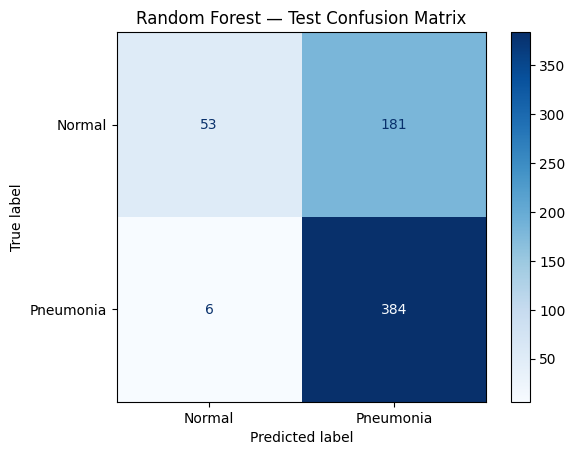

In [ ]:
# ── Random Forest Classifier ──────────────────────────────────────────────────
# Random Forest is an ensemble method that builds multiple decision trees
# and aggregates their predictions. Key parameters:
#   n_estimators=200        : number of trees in the forest
#   class_weight='balanced' : adjusts weights inversely proportional to
#                             class frequencies to handle class imbalance
#   n_jobs=-1               : use all available CPU cores for parallel training

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

print("Training Random Forest...")
start = time.time()
rf_model.fit(X_train_scaled, y_train)
print(f"Training complete! ({time.time() - start:.1f}s)")

# Evaluate on test set
rf_test_pred = rf_model.predict(X_test_scaled)

print("\nRandom Forest — Test Results")
print(f"Accuracy: {accuracy_score(y_test, rf_test_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_test_pred))

# Confusion matrix on test set
cm = confusion_matrix(y_test, rf_test_pred, labels=["Normal", "Pneumonia"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Normal", "Pneumonia"])
disp.plot(cmap="Blues")
plt.title("Random Forest — Test Confusion Matrix")
plt.show()

## Random Forest Results

The Random Forest classifier achieved an accuracy of 70.0% on the test set.

As shown in the confusion matrix, the model correctly identified most pneumonia cases, achieving a recall of 98% for the Pneumonia class. However, it struggled to recognize Normal X-rays, correctly classifying only 53 out of 234 normal images.

This indicates that the model is strongly biased toward predicting the majority class (Pneumonia). While this behavior minimizes missed pneumonia cases, it also produces a large number of false positives, reducing the overall balance of the classifier.

Training Linear SVM...
Training complete! (89.5s)

Linear SVM — Test Results
Accuracy: 0.7388

Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.32      0.48       234
   Pneumonia       0.71      0.99      0.83       390

    accuracy                           0.74       624
   macro avg       0.83      0.66      0.65       624
weighted avg       0.80      0.74      0.70       624



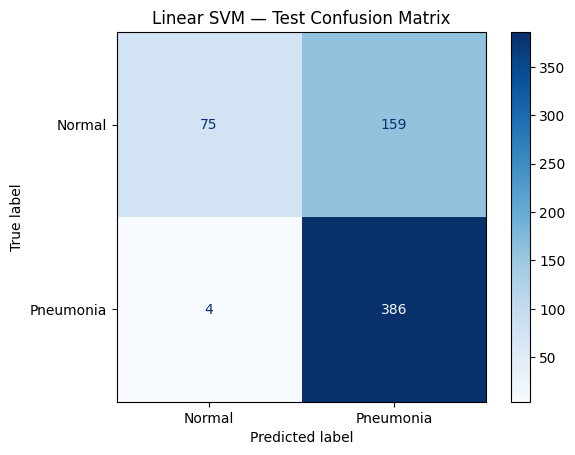

In [ ]:
# ── Linear SVM Classifier ─────────────────────────────────────────────────────
# Support Vector Machine with a linear kernel finds the optimal hyperplane
# that maximizes the margin between classes in the high-dimensional feature space.
# Key parameters:
#   kernel='linear'         : linear decision boundary
#   class_weight='balanced' : handles class imbalance by adjusting weights

linear_svm_model = SVC(
    kernel="linear",
    class_weight="balanced",
    random_state=SEED
)

print("Training Linear SVM...")
start = time.time()
linear_svm_model.fit(X_train_scaled, y_train)
print(f"Training complete! ({time.time() - start:.1f}s)")

# Evaluate on test set
linear_svm_test_pred = linear_svm_model.predict(X_test_scaled)

print("\nLinear SVM — Test Results")
print(f"Accuracy: {accuracy_score(y_test, linear_svm_test_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, linear_svm_test_pred))

# Confusion matrix on test set
cm = confusion_matrix(y_test, linear_svm_test_pred, labels=["Normal", "Pneumonia"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Normal", "Pneumonia"])
disp.plot(cmap="Blues")
plt.title("Linear SVM — Test Confusion Matrix")
plt.show()

## Linear SVM Results

The Linear SVM achieved an accuracy of 73.9% on the test set, outperforming the Random Forest classifier.

The model correctly identified 386 out of 390 pneumonia cases, resulting in an almost perfect recall of 99% for the Pneumonia class. It also improved the recognition of Normal cases compared to Random Forest, increasing the Normal class recall from 23% to 32%.

Despite this improvement, the classifier still produced a large number of false positives, predicting many Normal X-rays as Pneumonia. Overall, the Linear SVM provided a more balanced performance than Random Forest, but its ability to distinguish healthy lungs remained limited.

# Deep Learning Approaches


In this part, the models are trained directly on the X-ray images instead of using handcrafted features. The task remains binary classification, so the models are trained to distinguish between Normal and Pneumonia cases.

For the custom CNN, the pixel values are rescaled to the range [0, 1]. Data augmentation is applied only to the training set, using small transformations to make the model more robust without changing the medical meaning of the images.

In [ ]:
# ── Deep Learning Data Pipeline: Binary Classification ───────────────────────
# ImageDataGenerator handles rescaling and data augmentation.
#
# Augmentation (train only) — kept conservative for medical images:
#   - rotation_range=10     : slight rotation (patient positioning variation)
#   - zoom_range=0.10       : slight zoom (distance variation)
#   - width/height_shift    : small translations
#   - horizontal_flip=True  : applied as a data augmentation strategy
#                             to improve model generalization
#
# No augmentation on val/test — only rescaling to [0, 1].
# color_mode='rgb' : EfficientNetB0 expects 3-channel input;
#                    grayscale X-rays are replicated across 3 channels.

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

eval_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="binary_class",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_generator = eval_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="binary_class",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_generator = eval_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="binary_class",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Class mapping:")
print(train_generator.class_indices)

Found 4447 validated image filenames belonging to 2 classes.
Found 785 validated image filenames belonging to 2 classes.
Found 624 validated image filenames belonging to 2 classes.
Class mapping:
{'Normal': 0, 'Pneumonia': 1}


The generators correctly assign the two target classes as Normal and Pneumonia. The training generator also applies augmentation, while the validation and test generators only rescale the images. This keeps the evaluation data unchanged and allows a fairer assessment of model performance.

## Custom Convolutional Neural Network (CNN)

The first deep learning approach is a custom CNN trained from scratch on the chest X-ray dataset. Unlike the classical machine learning models, the network learns relevant image features automatically during training rather than relying on manually engineered descriptors such as HOG and GLCM.

A relatively simple architecture is used to provide a fair baseline and to investigate how well a lightweight CNN can perform on the pneumonia detection task.

In [ ]:
# ── Custom CNN Model ──────────────────────────────────────────────────────────
# A lightweight CNN trained from scratch on the chest X-ray dataset.
# Architecture:
#   3x [Conv2D → MaxPooling2D] blocks : extract hierarchical visual features
#   GlobalAveragePooling2D            : reduces spatial dimensions, avoids overfitting
#   Dense(128) + Dropout(0.4)         : classification head with regularization
#   Dense(1, sigmoid)                 : binary output (Normal / Pneumonia)
#
# Design choices:
#   - Filters double per block (32→64→128): capture increasingly complex features
#   - GlobalAveragePooling instead of Flatten: fewer parameters, better generalization
#   - Dropout(0.4): prevents overfitting on the relatively small dataset
#   - Adam(lr=1e-4): stable convergence for medical image classification

cnn_model = Sequential([
    Input(shape=(224, 224, 3)),
    Conv2D(32,  (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Conv2D(64,  (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

## Model Architecture

The network consists of three convolutional blocks followed by a small classification head. The convolutional layers progressively learn low-level and high-level image features, while the final dense layers perform the binary classification.

Global Average Pooling is used instead of a fully connected flattening layer in order to reduce the number of trainable parameters and limit overfitting. Dropout regularization is also included to improve generalization.

## Training Strategy

To improve training stability and reduce overfitting, callback functions are used during model training. These callbacks automatically monitor the validation loss and adjust the training process when performance stops improving.

Early stopping prevents unnecessary training once the model has converged, while learning rate reduction allows the optimizer to make smaller updates and potentially reach a better solution.

In [ ]:
# ── Training Callbacks ────────────────────────────────────────────────────────
# EarlyStopping: stops training when val_loss stops improving,
#   restores the best weights found during training.
#   patience=5 : wait 5 epochs before stopping
#
# ReduceLROnPlateau: reduces learning rate when val_loss plateaus,
#   helping the model escape local minima.
#   factor=0.5  : halve the learning rate
#   patience=2  : wait 2 epochs before reducing
#   min_lr=1e-6 : minimum learning rate allowed

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Separate callback for EfficientNetB0 fine-tuning — stricter patience
early_stop_ft = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

## Model Training

The custom CNN is trained for a maximum of 20 epochs using the augmented training data. During training, the model performance is monitored on the validation set, while the callback functions automatically control early stopping and learning rate adjustments.

The objective is to determine whether a relatively simple CNN can learn meaningful patterns directly from chest X-ray images and outperform the classical machine learning approaches.

In [ ]:
# ── Train Custom CNN ──────────────────────────────────────────────────────────
# Train for up to 20 epochs with early stopping.
# The model will stop early if val_loss does not improve for 5 consecutive epochs,
# and restore the best weights automatically.

EPOCHS = 20

print("Training Custom CNN...")
start = time.time()

cnn_history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\nTraining complete! ({time.time() - start:.1f}s)")

Training Custom CNN...
Epoch 1/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 109s 718ms/step - accuracy: 0.7396 - loss: 0.5922 - val_accuracy: 0.7427 - val_loss: 0.5822 - learning_rate: 1.0000e-04
Epoch 2/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 91s 657ms/step - accuracy: 0.7421 - loss: 0.5804 - val_accuracy: 0.7427 - val_loss: 0.5811 - learning_rate: 1.0000e-04
Epoch 3/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 92s 665ms/step - accuracy: 0.7421 - loss: 0.5735 - val_accuracy: 0.7427 - val_loss: 0.5602 - learning_rate: 1.0000e-04
Epoch 4/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 92s 664ms/step - accuracy: 0.7425 - loss: 0.5488 - val_accuracy: 0.7427 - val_loss: 0.5110 - learning_rate: 1.0000e-04
Epoch 5/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 95s 682ms/step - accuracy: 0.7571 - loss: 0.4905 - val_accuracy: 0.7885 - val_loss: 0.4302 - learning_rate: 1.0000e-04
Epoch 6/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 91s 656ms/step - accuracy: 0.8037 - loss: 0.4378 - val_accuracy: 0.8484 - val_loss: 0.3728 - learning_rate: 1.0000e-04
Epoch 7/20
139/139 ━━━

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 256ms/step
Custom CNN — Test Results
Accuracy: 0.7885

Classification Report:
              precision    recall  f1-score   support

      Normal       0.79      0.60      0.68       234
   Pneumonia       0.79      0.90      0.84       390

    accuracy                           0.79       624
   macro avg       0.79      0.75      0.76       624
weighted avg       0.79      0.79      0.78       624



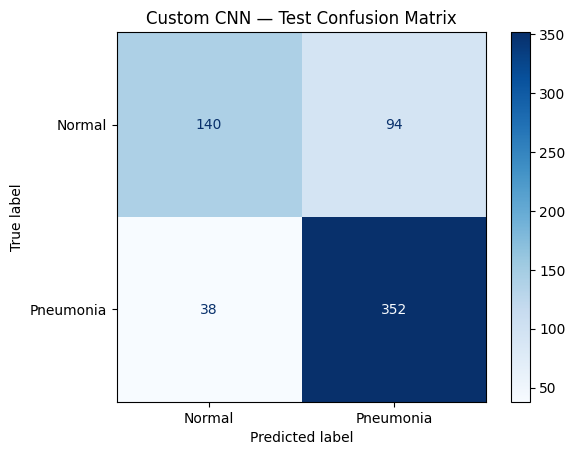

In [ ]:
# ── Custom CNN Evaluation ─────────────────────────────────────────────────────
# Evaluate the trained CNN on the held-out test set.
# The model outputs probabilities → threshold at 0.5 for binary predictions.
# Note: test_generator.classes gives the true labels in the correct order
#       (shuffle=False ensures alignment with predictions).

cnn_probabilities = cnn_model.predict(test_generator)
cnn_predictions   = (cnn_probabilities > 0.5).astype(int).flatten()
true_labels       = test_generator.classes

print("Custom CNN — Test Results")
print(f"Accuracy: {accuracy_score(true_labels, cnn_predictions):.4f}")
print("\nClassification Report:")
print(classification_report(true_labels, cnn_predictions,
                             target_names=["Normal", "Pneumonia"]))

# Confusion matrix on test set
cm = confusion_matrix(true_labels, cnn_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Normal", "Pneumonia"])
disp.plot(cmap="Blues")
plt.title("Custom CNN — Test Confusion Matrix")
plt.show()

## Custom CNN Results

The custom CNN achieved an accuracy of 78.9% on the test set, outperforming both classical machine learning models.

Compared to Random Forest and Linear SVM, the CNN provided a more balanced classification performance across the two classes. The model correctly identified 140 Normal cases and 352 Pneumonia cases, resulting in a substantial improvement in the Normal class recall.

The results suggest that learning features directly from the images is more effective than relying on handcrafted HOG and GLCM descriptors. Although some false positives and false negatives remain, the CNN demonstrates a clear improvement in overall classification performance and class balance.

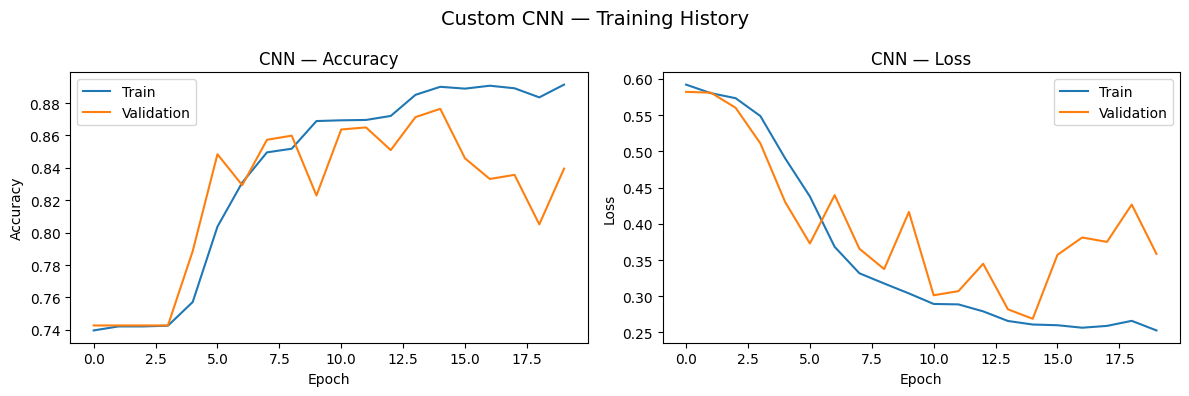

In [ ]:
# ── Training History ──────────────────────────────────────────────────────────
# Plot training and validation accuracy/loss curves to assess:
#   - Convergence: is the model learning steadily?
#   - Overfitting: is there a large gap between train and val curves?

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(cnn_history.history["accuracy"],     label="Train")
plt.plot(cnn_history.history["val_accuracy"], label="Validation")
plt.title("CNN — Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history["loss"],     label="Train")
plt.plot(cnn_history.history["val_loss"], label="Validation")
plt.title("CNN — Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.suptitle("Custom CNN — Training History", fontsize=14)
plt.tight_layout()
plt.show()

## Training History Analysis

The training curves show that the model steadily improved throughout the training process. Both training accuracy and validation accuracy increased significantly during the first epochs, indicating that the CNN successfully learned meaningful image features.

A small gap between the training and validation curves appears in the later stages of training, suggesting mild overfitting. However, the validation performance remained relatively stable, indicating that the applied regularization techniques, including data augmentation and dropout, helped maintain good generalization.

Overall, the training history suggests that the model converged successfully and achieved a reasonable balance between learning capacity and generalization.


## Transfer Learning with EfficientNetB0

To further improve performance, a transfer learning approach is used with EfficientNetB0. Unlike the custom CNN, this model starts from pretrained ImageNet weights, so it already contains useful general image features.

A separate data pipeline is created for EfficientNetB0 because this model includes its own internal preprocessing layers. Therefore, the images are not manually rescaled in the generator, unlike in the custom CNN pipeline.

In [ ]:
# ── Data Pipeline for EfficientNetB0 ─────────────────────────────────────────
# EfficientNetB0 includes its own preprocessing (rescaling + normalization)
# internally, so we must NOT apply rescale=1./255 in the generator.

eff_train_datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

eff_eval_datagen = ImageDataGenerator()

eff_train_generator = eff_train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="binary_class",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

eff_val_generator = eff_eval_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="binary_class",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

eff_test_generator = eff_eval_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="binary_class",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 4447 validated image filenames belonging to 2 classes.
Found 785 validated image filenames belonging to 2 classes.
Found 624 validated image filenames belonging to 2 classes.


The EfficientNetB0 generators use the same binary labels as the previous models, keeping the task consistent as Normal versus Pneumonia classification. Augmentation is again applied only to the training data, while validation and test images remain unchanged.

## EfficientNetB0 Model Architecture

EfficientNetB0 is used as a pretrained feature extractor. In the first phase, the convolutional base is frozen so that only the newly added classification layers are trained on the chest X-ray dataset.

A small custom classification head is added on top of the pretrained network. This allows the model to adapt the general image features learned from ImageNet to the binary pneumonia detection task.

In [ ]:
# ── EfficientNetB0 Model Definition ──────────────────────────────────────────
# Rebuild the model from scratch with the correct preprocessing pipeline.
# EfficientNetB0 includes internal rescaling and normalization layers,
# so the ImageDataGenerator must NOT apply rescale=1./255.

base_network= EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_network.trainable = False  # freeze the base for Phase 1

# Add custom classification head
x      = base_network.output
x      = GlobalAveragePooling2D()(x)
x      = Dropout(0.3)(x)
x      = Dense(128, activation="relu")(x)
x      = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)

efficientnet_model = Model(inputs=base_network.input, outputs=output)

# lr=1e-4 is appropriate for training only the classification head
efficientnet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In this phase, most of the EfficientNetB0 parameters remain frozen. This reduces the risk of overfitting and allows the model to first learn a suitable classification head before applying fine-tuning in the next step.

## Phase 1: Feature Extraction

The first training stage focuses only on the custom classification head, while the pretrained EfficientNetB0 backbone remains frozen.

This approach allows the newly added layers to adapt to the chest X-ray classification task without modifying the pretrained feature representations. It also provides a stable starting point before fine-tuning part of the backbone network in the next phase.

In [ ]:
# ── Train EfficientNetB0 — Phase 1: Feature Extraction ───────────────────────
# Train only the classification head with the frozen base.

print("Training EfficientNetB0 (Phase 1 — frozen base)...")
start = time.time()

efficientnet_history = efficientnet_model.fit(
    eff_train_generator,
    validation_data=eff_val_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\nPhase 1 complete! ({time.time() - start:.1f}s)")

Training EfficientNetB0 (Phase 1 — frozen base)...
Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 157s 917ms/step - accuracy: 0.8098 - loss: 0.4043 - val_accuracy: 0.8790 - val_loss: 0.2660 - learning_rate: 1.0000e-04
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 89s 639ms/step - accuracy: 0.8952 - loss: 0.2409 - val_accuracy: 0.9045 - val_loss: 0.2207 - learning_rate: 1.0000e-04
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 90s 648ms/step - accuracy: 0.9150 - loss: 0.2010 - val_accuracy: 0.9146 - val_loss: 0.2036 - learning_rate: 1.0000e-04
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 89s 640ms/step - accuracy: 0.9305 - loss: 0.1815 - val_accuracy: 0.9172 - val_loss: 0.1919 - learning_rate: 1.0000e-04
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 90s 646ms/step - accuracy: 0.9258 - loss: 0.1765 - val_accuracy: 0.9236 - val_loss: 0.1868 - learning_rate: 1.0000e-04
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 91s 652ms/step - accuracy: 0.9321 - loss: 0.1670 - val_accuracy: 0.9223 - val_loss: 0.1968 - learning_rate: 1.000

## Phase 1 Results

The model completed all 10 epochs without triggering EarlyStopping. The best validation loss was observed at epoch 8, while training continued until the predefined maximum number of epochs was reached. The model converged quickly during the feature extraction stage, reaching high validation accuracy while keeping the pretrained backbone frozen.

This indicates that the ImageNet features learned by EfficientNetB0 transfer effectively to the pneumonia detection task. The strong validation performance suggests that the extracted features already contain useful information for distinguishing between Normal and Pneumonia X-rays.

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 231ms/step
EfficientNetB0 — Test Results (Phase 1: Frozen Base)
Accuracy: 0.8574

Classification Report:
              precision    recall  f1-score   support

      Normal       0.87      0.73      0.79       234
   Pneumonia       0.85      0.93      0.89       390

    accuracy                           0.86       624
   macro avg       0.86      0.83      0.84       624
weighted avg       0.86      0.86      0.85       624



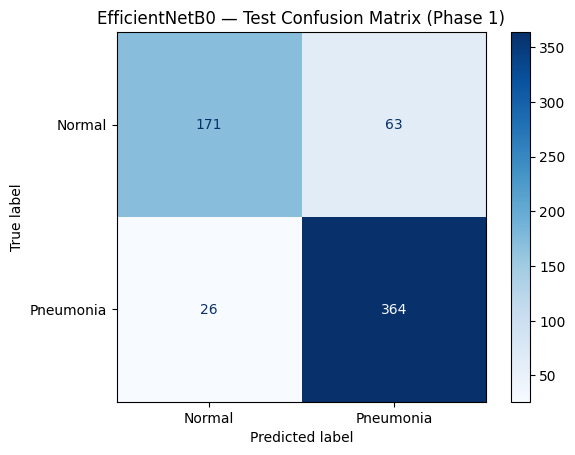

In [ ]:
# ── EfficientNetB0 Evaluation — Phase 1 ──────────────────────────────────────
# Evaluate the frozen model before fine-tuning to compare with Phase 2 results.

eff_probs_ph1       = efficientnet_model.predict(eff_test_generator)
eff_predictions_ph1 = (eff_probs_ph1 > 0.5).astype(int).flatten()
true_labels         = eff_test_generator.classes

print("EfficientNetB0 — Test Results (Phase 1: Frozen Base)")
print(f"Accuracy: {accuracy_score(true_labels, eff_predictions_ph1):.4f}")
print("\nClassification Report:")
print(classification_report(true_labels, eff_predictions_ph1,
                             target_names=["Normal", "Pneumonia"]))

cm = confusion_matrix(true_labels, eff_predictions_ph1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Normal", "Pneumonia"])
disp.plot(cmap="Blues")
plt.title("EfficientNetB0 — Test Confusion Matrix (Phase 1)")
plt.show()

## EfficientNetB0 Phase 1 Results

The pretrained EfficientNetB0 model achieved an accuracy of 85.7% on the test set, representing a substantial improvement over both the classical machine learning models and the custom CNN.

The model correctly classified 171 Normal cases and 364 Pneumonia cases, achieving strong performance for both classes. Unlike the Random Forest and Linear SVM models, which were heavily biased toward predicting Pneumonia, EfficientNetB0 provided a much more balanced classification performance.

These results highlight the effectiveness of transfer learning, as the pretrained image features learned from ImageNet were successfully adapted to the pneumonia detection task with only the classification head being trained.

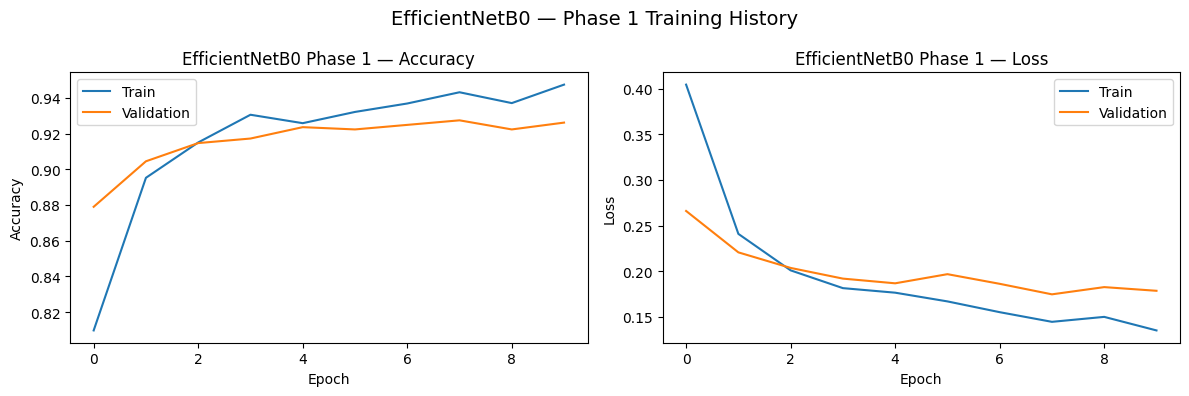

In [ ]:
# ── EfficientNetB0 Training History — Phase 1 ────────────────────────────────
# Plot accuracy and loss curves after Phase 1 (frozen base, head-only training).

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(efficientnet_history.history["accuracy"],     label="Train")
plt.plot(efficientnet_history.history["val_accuracy"], label="Validation")
plt.title("EfficientNetB0 Phase 1 — Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(efficientnet_history.history["loss"],     label="Train")
plt.plot(efficientnet_history.history["val_loss"], label="Validation")
plt.title("EfficientNetB0 Phase 1 — Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.suptitle("EfficientNetB0 — Phase 1 Training History", fontsize=14)
plt.tight_layout()
plt.show()

## Phase 1 Training History

The training curves show stable and consistent learning throughout the feature extraction stage. Validation accuracy increased rapidly during the first few epochs and remained above 92% for the rest of the training process.

The validation loss generally decreased over time and remained relatively close to the training loss, suggesting that the model generalized well to unseen data. Although a small gap between the training and validation curves appeared in the later epochs, there is no evidence of severe overfitting.

Overall, the results indicate that the pretrained EfficientNetB0 features transfer effectively to the chest X-ray classification task, even before any fine-tuning of the backbone network.

## Phase 2: Fine-Tuning

After training the classification head, the next step is to fine-tune the upper layers of EfficientNetB0. The earlier layers are kept frozen because they capture more general visual features, while the later layers are allowed to adapt to chest X-ray patterns.

A smaller learning rate is used during fine-tuning to avoid large updates that could damage the pretrained weights.

In [ ]:
# ── EfficientNetB0 Phase 2: Fine-Tuning ──────────────────────────────────────
# Unfreeze the top 50 layers (instead of 30) and fine-tune with a smaller lr.
# Early layers capture generic features — keep them frozen.
# Later layers capture high-level features — adapt them to X-ray patterns.

base_network.trainable = True

# Freeze all layers except the last 50
for layer in base_network.layers[:-50]:
    layer.trainable = False

# Recompile with smaller lr to avoid destroying pretrained weights
efficientnet_model.compile(
    optimizer=Adam(learning_rate=5e-6),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print(f"Trainable layers: {sum(1 for l in efficientnet_model.layers if l.trainable)}")

print("Fine-tuning EfficientNetB0 (Phase 2)...")
start = time.time()

fine_tune_history = efficientnet_model.fit(
    eff_train_generator,
    validation_data=eff_val_generator,
    epochs=10,
    callbacks=[early_stop_ft, reduce_lr],  # ← early_stop_ft με patience=3
    verbose=1
)

print(f"\nFine-tuning complete! ({time.time() - start:.1f}s)")

Trainable layers: 35
Fine-tuning EfficientNetB0 (Phase 2)...
Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 151s 839ms/step - accuracy: 0.9197 - loss: 0.2429 - val_accuracy: 0.9083 - val_loss: 0.2543 - learning_rate: 5.0000e-06
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 91s 653ms/step - accuracy: 0.9247 - loss: 0.2138 - val_accuracy: 0.9146 - val_loss: 0.2345 - learning_rate: 5.0000e-06
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 89s 640ms/step - accuracy: 0.9341 - loss: 0.1892 - val_accuracy: 0.9159 - val_loss: 0.2174 - learning_rate: 5.0000e-06
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 89s 639ms/step - accuracy: 0.9373 - loss: 0.1759 - val_accuracy: 0.9172 - val_loss: 0.2085 - learning_rate: 5.0000e-06
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 90s 650ms/step - accuracy: 0.9397 - loss: 0.1657 - val_accuracy: 0.9210 - val_loss: 0.1959 - learning_rate: 5.0000e-06
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 90s 644ms/step - accuracy: 0.9465 - loss: 0.1539 - val_accuracy: 0.9223 - val_loss: 0.1921 - learning_r

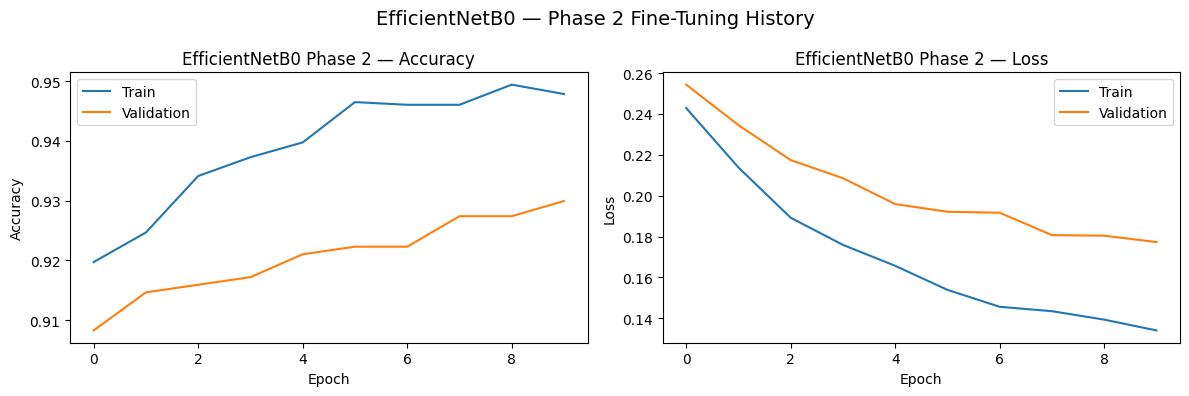

In [ ]:
# ── EfficientNetB0 Training History — Phase 2 ────────────────────────────────
# Plot accuracy and loss curves after Phase 2 fine-tuning.

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(fine_tune_history.history["accuracy"],     label="Train")
plt.plot(fine_tune_history.history["val_accuracy"], label="Validation")
plt.title("EfficientNetB0 Phase 2 — Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(fine_tune_history.history["loss"],     label="Train")
plt.plot(fine_tune_history.history["val_loss"], label="Validation")
plt.title("EfficientNetB0 Phase 2 — Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.suptitle("EfficientNetB0 — Phase 2 Fine-Tuning History", fontsize=14)
plt.tight_layout()
plt.show()

## Fine-Tuning Analysis

The fine-tuning stage resulted in a small but consistent improvement in validation performance. Both validation accuracy and validation loss continued to improve throughout training, indicating that the unfrozen EfficientNetB0 layers successfully adapted to the chest X-ray classification task.

The gap between the training and validation curves remained relatively small, suggesting that the model maintained good generalization despite the increased number of trainable parameters. The gradual decrease in validation loss also indicates that the low learning rate helped preserve the useful pretrained features while allowing task-specific adaptation.

Overall, the training curves suggest that fine-tuning was beneficial and further improved the model beyond the frozen-base configuration.

20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 586ms/step
EfficientNetB0 Fine-Tuned — Test Results
Accuracy: 0.8718

Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.71      0.80       234
   Pneumonia       0.85      0.97      0.90       390

    accuracy                           0.87       624
   macro avg       0.89      0.84      0.85       624
weighted avg       0.88      0.87      0.87       624



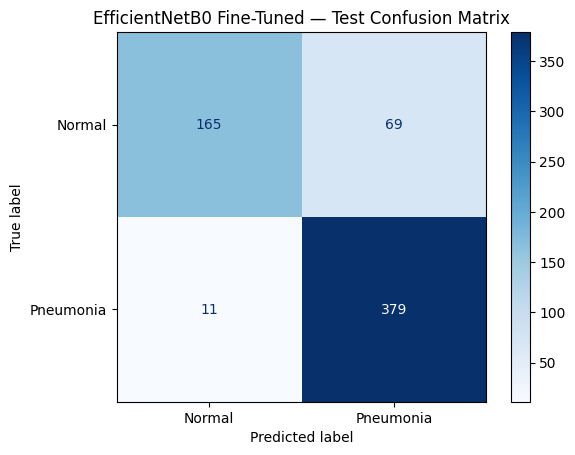

In [ ]:
# ── EfficientNetB0 Final Evaluation ──────────────────────────────────────────
# Evaluate the fine-tuned model on the held-out test set.

eff_probs       = efficientnet_model.predict(eff_test_generator)
eff_predictions = (eff_probs > 0.5).astype(int).flatten()
true_labels     = eff_test_generator.classes

print("EfficientNetB0 Fine-Tuned — Test Results")
print(f"Accuracy: {accuracy_score(true_labels, eff_predictions):.4f}")
print("\nClassification Report:")
print(classification_report(true_labels, eff_predictions,
                             target_names=["Normal", "Pneumonia"]))

cm = confusion_matrix(true_labels, eff_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Normal", "Pneumonia"])
disp.plot(cmap="Blues")
plt.title("EfficientNetB0 Fine-Tuned — Test Confusion Matrix")
plt.show()

## Fine-Tuned EfficientNetB0 Results

The fine-tuned EfficientNetB0 achieved the best overall performance among all evaluated models, reaching an accuracy of 87.2% on the test set.

The model correctly classified 165 Normal cases and 379 Pneumonia cases, resulting in strong performance for both classes. In particular, the Pneumonia class achieved a recall of 97%, meaning that only 11 pneumonia cases were missed in the test set.

Compared to the frozen-base version, fine-tuning provided a modest but measurable improvement in accuracy and overall classification performance. The results indicate that adapting the higher-level EfficientNetB0 features to chest X-ray images was beneficial and further improved the model's ability to distinguish between healthy and infected lungs.

Overall, the fine-tuned EfficientNetB0 was the most effective model in this study and achieved the best balance between sensitivity to pneumonia cases and recognition of normal X-rays.

# Model Comparison and Discussion



The performance of all models is summarized and compared in the following section. The objective is to evaluate the impact of handcrafted features, custom deep learning architectures, and transfer learning on the pneumonia detection task.

Model                            Accuracy  F1 Normal  F1 Pneumonia   F1 Macro
Random Forest                      0.7003       0.36          0.80       0.58
Linear SVM                         0.7388       0.48          0.83       0.65
Custom CNN                         0.7885       0.68          0.84       0.76
EfficientNetB0 (Phase 1)           0.8574       0.79          0.89       0.84
EfficientNetB0 (Fine-Tuned)        0.8718       0.80          0.90       0.85


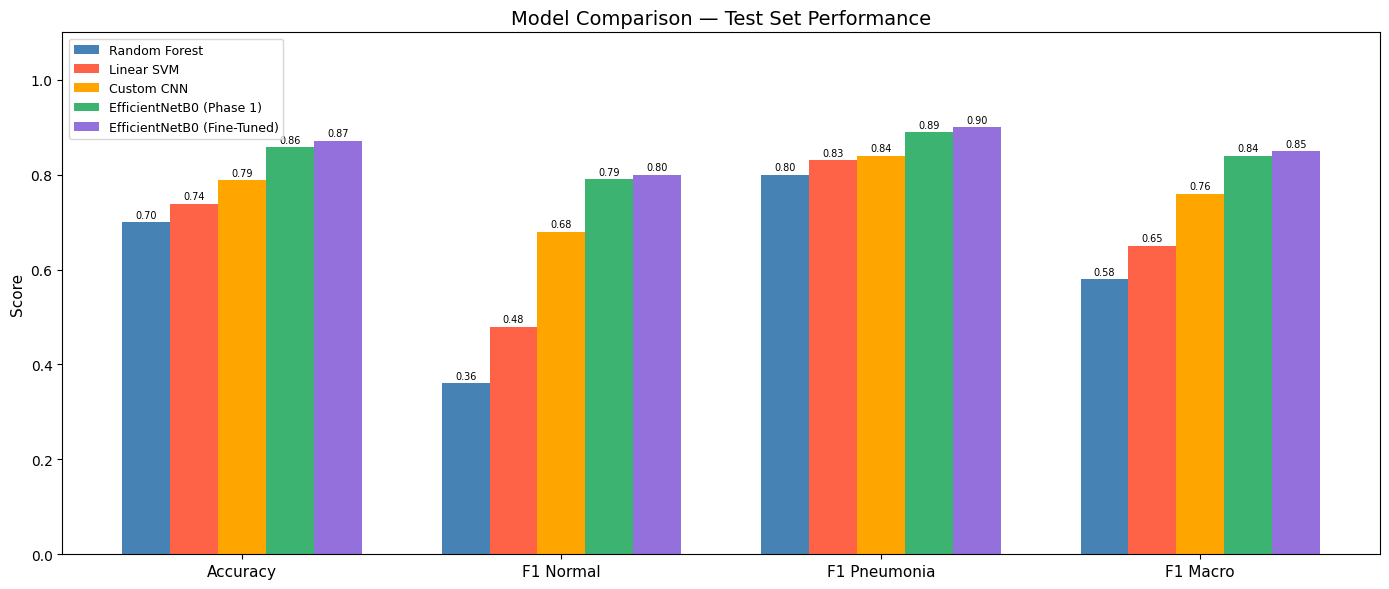

In [ ]:
# ── Final Model Comparison ────────────────────────────────────────────────────
# Summary of all models evaluated on the held-out test set.
# Metrics: Accuracy, F1-score for each class, and Macro F1.

results = {
    "Model": [
        "Random Forest",
        "Linear SVM",
        "Custom CNN",
        "EfficientNetB0 (Phase 1)",
        "EfficientNetB0 (Fine-Tuned)"
    ],
    "Accuracy": [0.7003, 0.7388, 0.7885, 0.8574, 0.8718],
    "F1 Normal": [0.36, 0.48, 0.68, 0.79, 0.80],
    "F1 Pneumonia": [0.80, 0.83, 0.84, 0.89, 0.90],
    "F1 Macro": [0.58, 0.65, 0.76, 0.84, 0.85],
}

df_results = pd.DataFrame(results)

# ── Table ─────────────────────────────────────────────────────────────────────
print("=" * 75)
print(f"{'Model':<30} {'Accuracy':>10} {'F1 Normal':>10} {'F1 Pneumonia':>13} {'F1 Macro':>10}")
print("=" * 75)
for _, row in df_results.iterrows():
    print(f"{row['Model']:<30} {row['Accuracy']:>10.4f} {row['F1 Normal']:>10.2f} {row['F1 Pneumonia']:>13.2f} {row['F1 Macro']:>10.2f}")
print("=" * 75)

# ── Bar Chart ─────────────────────────────────────────────────────────────────
metrics = ["Accuracy", "F1 Normal", "F1 Pneumonia", "F1 Macro"]
models  = df_results["Model"].tolist()
x       = np.arange(len(metrics))
width   = 0.15
colors  = ["steelblue", "tomato", "orange", "mediumseagreen", "mediumpurple"]

fig, ax = plt.subplots(figsize=(14, 6))

for i, (model, color) in enumerate(zip(models, colors)):
    values = df_results[df_results["Model"] == model][metrics].values[0]
    bars   = ax.bar(x + i * width, values, width=width, label=model, color=color)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.2f}",
                ha="center", va="bottom", fontsize=7)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Model Comparison — Test Set Performance", fontsize=14)
ax.set_ylim(0, 1.1)
ax.legend(loc="upper left", fontsize=9)


plt.tight_layout()
plt.show()

## Model Comparison

The results show a clear performance progression as the complexity of the models increases.

Among the classical machine learning approaches, the Linear SVM outperformed Random Forest across all evaluation metrics. However, both models struggled to correctly identify Normal X-rays, resulting in relatively low F1 scores for the Normal class.

The custom CNN achieved a noticeable improvement over the classical models, demonstrating the advantage of learning image features directly from the data instead of relying on handcrafted descriptors. In particular, the F1 score for the Normal class increased substantially, indicating a more balanced classification performance.

The best results were obtained with EfficientNetB0. Even with a frozen backbone, the transfer learning approach significantly outperformed the custom CNN. Fine-tuning the upper layers of the network provided an additional improvement, resulting in the highest accuracy (87.2%) and the best overall F1 scores.

Overall, the results suggest that transfer learning is the most effective approach for pneumonia detection in this dataset. The pretrained EfficientNetB0 model was able to leverage general visual features learned from large-scale image datasets and successfully adapt them to chest X-ray classification.

In [ ]:
# ── Data Pipeline for 3-Class EfficientNetB0 ─────────────────────────────────
# For the 3-class problem we use detailed_class as the target label:
#   Normal / Bacterial Pneumonia / Viral Pneumonia
# class_mode='categorical' for one-hot encoded labels.

eff3_train_datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

eff3_eval_datagen = ImageDataGenerator()

eff3_train_generator = eff3_train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="detailed_class",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

eff3_val_generator = eff3_eval_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="detailed_class",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

eff3_test_generator = eff3_eval_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="detailed_class",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Class mapping:")
print(eff3_train_generator.class_indices)

Found 4447 validated image filenames belonging to 3 classes.
Found 785 validated image filenames belonging to 3 classes.
Found 624 validated image filenames belonging to 3 classes.
Class mapping:
{'Bacterial Pneumonia': 0, 'Normal': 1, 'Viral Pneumonia': 2}


#Experiment: 3-Class Classification



As an additional experiment, the binary classification problem is extended to three classes: Normal, Bacterial Pneumonia, and Viral Pneumonia.

Although this is not the primary objective of the project, it provides a more detailed evaluation of the dataset and investigates whether the model can distinguish between different types of pneumonia rather than simply detecting the presence of the disease.



## EfficientNetB0 Architecture for 3-Class Classification

The same EfficientNetB0 architecture is reused for the three-class experiment. The main difference is that the final output layer now contains three neurons with a softmax activation function, allowing the model to predict Normal, Bacterial Pneumonia, and Viral Pneumonia.

As in the binary classification setup, the pretrained EfficientNetB0 backbone is initially frozen and used as a feature extractor, while the newly added classification head is trained on the chest X-ray dataset.

In [ ]:
# ── EfficientNetB0 3-Class Model Definition ───────────────────────────────────
# Same architecture as binary model but with:
#   Dense(3, softmax) : 3-class output
#   categorical_crossentropy : multi-class loss

base_network_3 = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_network_3.trainable = False

x      = base_network_3.output
x      = GlobalAveragePooling2D()(x)
x      = Dropout(0.3)(x)
x      = Dense(128, activation="relu")(x)
x      = Dropout(0.3)(x)
output = Dense(3, activation="softmax")(x)

eff3_model = Model(inputs=base_network_3.input, outputs=output)

eff3_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

eff3_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,213,926 (16.07 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

The architecture remains identical to the binary classification model, with the only modifications being the three-neuron softmax output layer and the use of categorical cross-entropy loss. This design enables a direct comparison between the binary and three-class classification settings while keeping the underlying feature extraction architecture unchanged.

## Phase 1 Training

The three-class EfficientNetB0 model is first trained using the frozen pretrained backbone. During this stage, only the classification head is updated, allowing the model to learn the differences between Normal, Bacterial Pneumonia, and Viral Pneumonia without modifying the pretrained image features.

This serves as the baseline configuration before applying fine-tuning in the next phase.

In [ ]:
# ── Train EfficientNetB0 3-Class — Phase 1 ────────────────────────────────────
print("Training EfficientNetB0 3-Class (Phase 1 — frozen base)...")
start = time.time()

eff3_history = eff3_model.fit(
    eff3_train_generator,
    validation_data=eff3_val_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\nPhase 1 complete! ({time.time() - start:.1f}s)")

Training EfficientNetB0 3-Class (Phase 1 — frozen base)...
Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 148s 830ms/step - accuracy: 0.5682 - loss: 0.9244 - val_accuracy: 0.6968 - val_loss: 0.7012 - learning_rate: 1.0000e-04
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - accuracy: 0.6932 - loss: 0.7109
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
139/139 ━━━━━━━━━━━━━━━━━━━━ 92s 662ms/step - accuracy: 0.6908 - loss: 0.6999 - val_accuracy: 0.7261 - val_loss: 0.6305 - learning_rate: 1.0000e-04
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 92s 662ms/step - accuracy: 0.7081 - loss: 0.6642 - val_accuracy: 0.7350 - val_loss: 0.6167 - learning_rate: 5.0000e-05
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.7168 - loss: 0.6308
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
139/139 ━━━━━━━━━━━━━━━━━━━━ 91s 658ms/step - accuracy: 0.7151 - loss: 0.6416 - val_accuracy: 0.7274 - val_loss: 0.6045 - learning_rate: 5.0000e-0

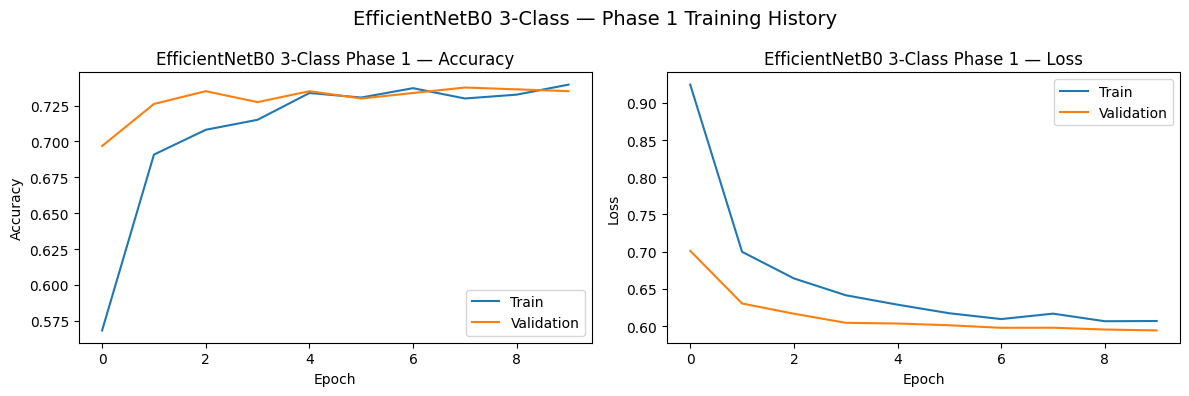

In [ ]:
# ── EfficientNetB0 3-Class Training History — Phase 1 ────────────────────────
# Plot accuracy and loss curves after Phase 1 (frozen base, 3-class training).

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(eff3_history.history["accuracy"],     label="Train")
plt.plot(eff3_history.history["val_accuracy"], label="Validation")
plt.title("EfficientNetB0 3-Class Phase 1 — Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(eff3_history.history["loss"],     label="Train")
plt.plot(eff3_history.history["val_loss"], label="Validation")
plt.title("EfficientNetB0 3-Class Phase 1 — Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.suptitle("EfficientNetB0 3-Class — Phase 1 Training History", fontsize=14)
plt.tight_layout()
plt.show()

## Phase 1 Training History

The training curves show that the model learned the three-class classification task effectively during the feature extraction stage. Both training and validation accuracy increased rapidly during the first few epochs before gradually stabilizing around 73–74%.

The validation curves closely follow the training curves, suggesting that the model generalized well and did not suffer from significant overfitting. Validation loss also decreased steadily throughout training, indicating consistent improvement in the model's predictions.

Compared to the binary classification experiments, the overall accuracy is lower, which is expected because the model must now distinguish between three classes instead of two. In particular, separating bacterial and viral pneumonia is a more challenging task than simply detecting the presence of pneumonia.

## Phase 2: Fine-Tuning

After training the classification head, the upper layers of the EfficientNetB0 backbone are unfrozen and fine-tuned using a small learning rate.

The goal is to adapt the pretrained image representations more specifically to the three-class chest X-ray classification task. Since the distinction between bacterial and viral pneumonia is more subtle than the binary Normal/Pneumonia setting, fine-tuning may help the model learn more discriminative features.

In [ ]:
# ── EfficientNetB0 3-Class — Phase 2: Fine-Tuning ────────────────────────────
base_network_3.trainable = True

for layer in base_network_3.layers[:-50]:
    layer.trainable = False

eff3_model.compile(
    optimizer=Adam(learning_rate=5e-6),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print(f"Trainable layers: {sum(1 for l in eff3_model.layers if l.trainable)}")

print("Fine-tuning EfficientNetB0 3-Class (Phase 2)...")
start = time.time()

eff3_fine_tune_history = eff3_model.fit(
    eff3_train_generator,
    validation_data=eff3_val_generator,
    epochs=10,
    callbacks=[early_stop_ft, reduce_lr],
    verbose=1
)

print(f"\nFine-tuning complete! ({time.time() - start:.1f}s)")

Trainable layers: 55
Fine-tuning EfficientNetB0 3-Class (Phase 2)...
Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.6431 - loss: 0.8017 - val_accuracy: 0.7236 - val_loss: 0.6669 - learning_rate: 5.0000e-06
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 708ms/step - accuracy: 0.6838 - loss: 0.7404
Epoch 2: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
139/139 ━━━━━━━━━━━━━━━━━━━━ 119s 856ms/step - accuracy: 0.6953 - loss: 0.7297 - val_accuracy: 0.7197 - val_loss: 0.6861 - learning_rate: 5.0000e-06
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 109s 785ms/step - accuracy: 0.7167 - loss: 0.6917 - val_accuracy: 0.7223 - val_loss: 0.6774 - learning_rate: 2.5000e-06

Fine-tuning complete! (404.8s)


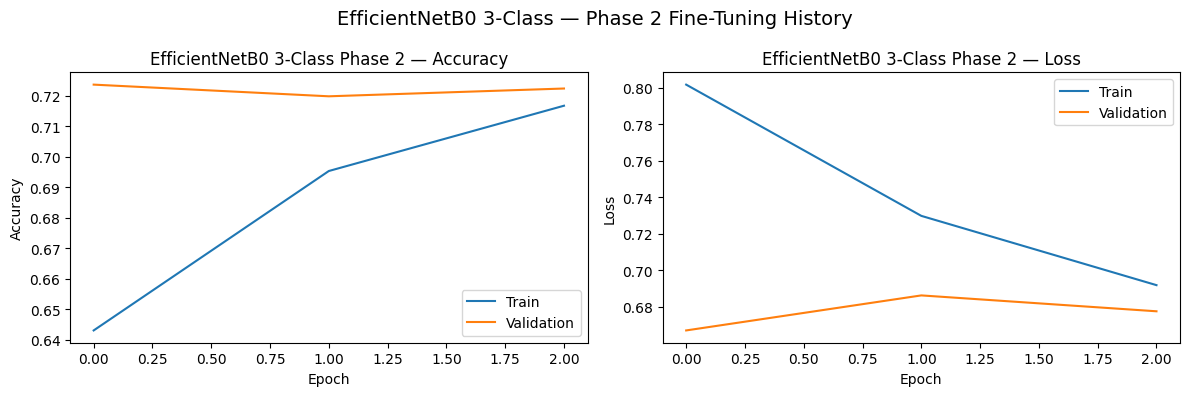

In [ ]:
# ── EfficientNetB0 3-Class Training History — Phase 2 ────────────────────────
# Plot accuracy and loss curves after Phase 2 fine-tuning (3-class).

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(eff3_fine_tune_history.history["accuracy"],     label="Train")
plt.plot(eff3_fine_tune_history.history["val_accuracy"], label="Validation")
plt.title("EfficientNetB0 3-Class Phase 2 — Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(eff3_fine_tune_history.history["loss"],     label="Train")
plt.plot(eff3_fine_tune_history.history["val_loss"], label="Validation")
plt.title("EfficientNetB0 3-Class Phase 2 — Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.suptitle("EfficientNetB0 3-Class — Phase 2 Fine-Tuning History", fontsize=14)
plt.tight_layout()
plt.show()

## Fine-Tuning Analysis

The fine-tuning stage produced only limited improvements compared to the frozen-base model. While the training accuracy continued to increase and the training loss decreased, the validation accuracy remained relatively stable at around 72%.

Similarly, the validation loss showed only minor changes throughout training, suggesting that the model had already extracted most of the useful information during the feature extraction stage.

This behavior indicates that the three-class classification task is substantially more challenging than the binary Normal/Pneumonia problem. In particular, distinguishing between bacterial and viral pneumonia appears to be difficult, even after adapting the higher-level EfficientNetB0 features through fine-tuning.

Overall, fine-tuning did not lead to the same level of improvement observed in the binary classification experiments, suggesting that the main limitation lies in the complexity of the task rather than the capacity of the model.

20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 599ms/step
EfficientNetB0 — 3-Class Test Results
Accuracy: 0.8061

Classification Report:
                     precision    recall  f1-score   support

Bacterial Pneumonia       0.80      0.87      0.84       242
             Normal       0.82      0.82      0.82       234
    Viral Pneumonia       0.78      0.68      0.73       148

           accuracy                           0.81       624
          macro avg       0.80      0.79      0.79       624
       weighted avg       0.81      0.81      0.80       624



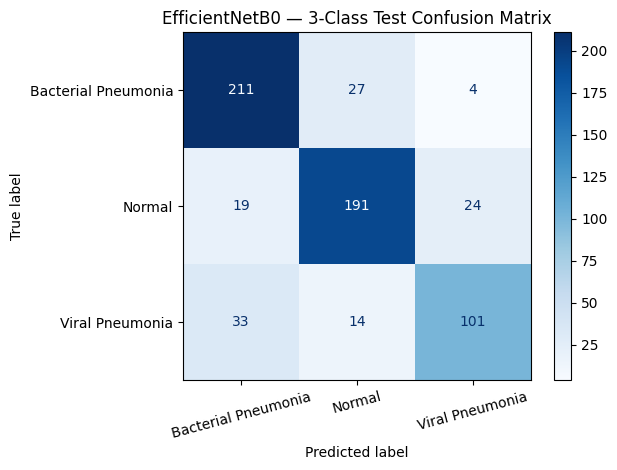

In [ ]:
# ── EfficientNetB0 3-Class Final Evaluation ───────────────────────────────────
# Get class mapping
class_indices  = eff3_test_generator.class_indices
class_names    = list(class_indices.keys())

eff3_probs       = eff3_model.predict(eff3_test_generator)
eff3_predictions = np.argmax(eff3_probs, axis=1)
true_labels_3    = eff3_test_generator.classes

print("EfficientNetB0 — 3-Class Test Results")
print(f"Accuracy: {accuracy_score(true_labels_3, eff3_predictions):.4f}")
print("\nClassification Report:")
print(classification_report(true_labels_3, eff3_predictions,
                             target_names=class_names))

# 3x3 Confusion matrix
cm = confusion_matrix(true_labels_3, eff3_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("EfficientNetB0 — 3-Class Test Confusion Matrix")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Final 3-Class Evaluation

The three-class EfficientNetB0 model achieved an overall test accuracy of 80.6%, demonstrating that the network was able to distinguish between Normal, Bacterial Pneumonia, and Viral Pneumonia with reasonable performance.

The best results were obtained for Bacterial Pneumonia, with an F1-score of 0.84, followed closely by the Normal class with an F1-score of 0.82. Viral Pneumonia proved to be the most challenging category, achieving an F1-score of 0.73.

The confusion matrix shows that most errors occurred between the two pneumonia subclasses. Several viral cases were misclassified as bacterial pneumonia, suggesting that the visual differences between these conditions are often subtle and difficult to capture, even with a pretrained deep learning model.

Although the three-class task achieved lower performance than the binary classification experiments, the results remain encouraging given the increased complexity of distinguishing between multiple disease categories rather than simply detecting the presence of pneumonia.

# Conclusions



This study investigated pneumonia detection from chest X-ray images using both classical machine learning and deep learning approaches.

Among the classical machine learning models, Linear SVM outperformed Random Forest, although both methods showed difficulty in identifying Normal cases consistently, resulting in relatively low F1-scores for the Normal class.

The custom CNN achieved noticeably better results, demonstrating the ability of convolutional networks to automatically learn discriminative image features directly from the data.

The best overall performance was obtained using EfficientNetB0 with transfer learning and fine-tuning, achieving an accuracy of 87.2% and the highest macro F1-score among all evaluated models. This highlights the benefit of leveraging pretrained visual representations for medical image analysis.

As an additional experiment, the problem was extended to three classes (Normal, Bacterial Pneumonia, and Viral Pneumonia). Although the classification task became substantially more challenging, the EfficientNetB0 model still achieved 80.6% accuracy, indicating that pretrained deep learning models can capture meaningful differences between pneumonia subtypes.

Overall, the results demonstrate that deep learning, particularly transfer learning with pretrained architectures, provides a significant advantage over traditional feature-based machine learning methods for chest X-ray pneumonia detection.